<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula02a_regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [16]:
def train_test_split(X, y, test_size=0.2, random_state=42):
  np.random.seed(random_state)
  indices = np.random.permutation(len(X))
  test_size = int(len(X) * test_size)
  test_indices = indices[:test_size]
  train_indices = indices[test_size:]
  X_train = X[train_indices]
  y_train = y[train_indices]
  X_test = X[test_indices]
  y_test = y[test_indices]
  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


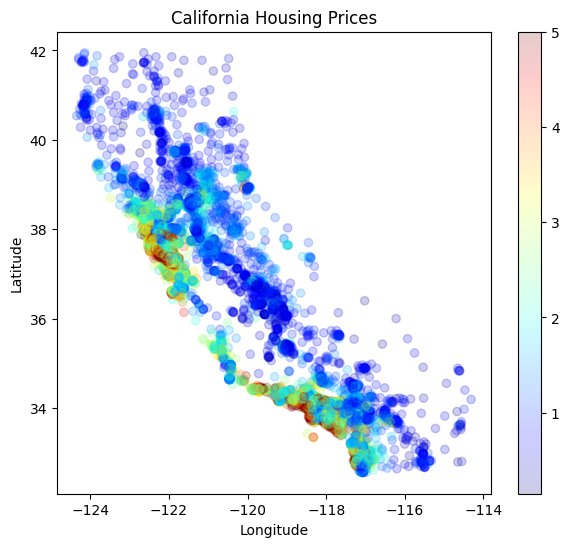

In [6]:
from matplotlib import pyplot as plt

feature_names = housing.feature_names

plt.figure(figsize=(7,6))
plt.scatter(X_train[:, feature_names.index("Longitude")],
            X_train[:, feature_names.index("Latitude")],
            c=y_train,
            cmap="jet", alpha=0.2)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices")
plt.show()

In [7]:
import pandas as pd

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


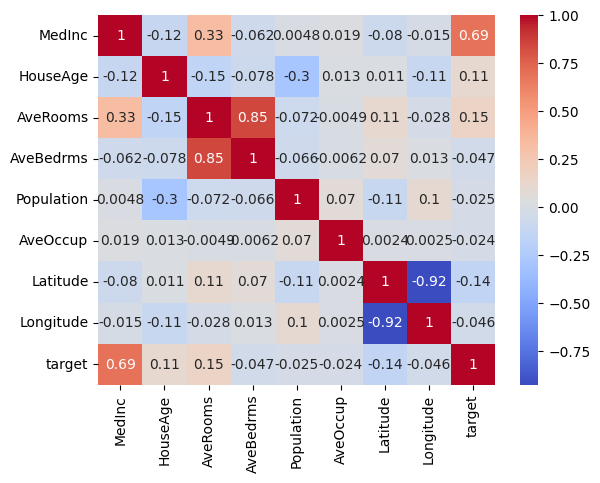

In [8]:
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [9]:
print(feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


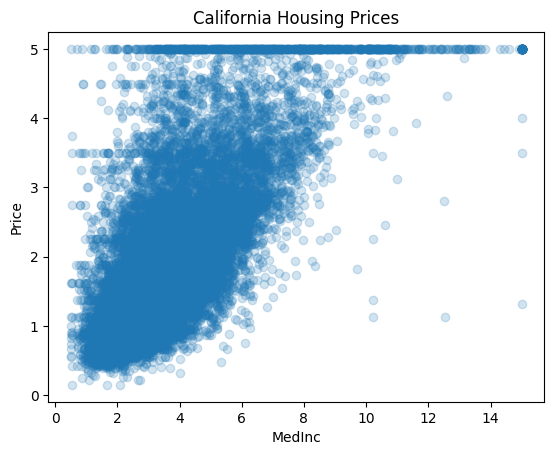

In [25]:
from matplotlib import pyplot as plt

def plot_regression_dataset(X, y, feature="MedInc"):
  plt.scatter(X[:, feature_names.index(feature)],
              y, alpha=0.2)
  plt.xlabel(feature)
  plt.ylabel("Price")
  plt.title("California Housing Prices")

plot_regression_dataset(X_train, y_train, "MedInc")
plt.show()

In [14]:
import numpy as np

def average_predictor(y):
  y_pred = np.ones_like(y) * y.mean()
  return y_pred

y_pred = average_predictor(y_train)
print(y_pred)

[2.07194694 2.07194694 2.07194694 ... 2.07194694 2.07194694 2.07194694]


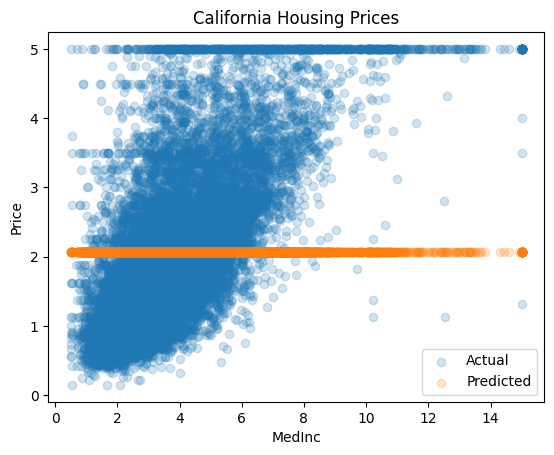

In [26]:
from matplotlib import pyplot as plt

def plot_predictions(y, y_pred, feature="MedInc"):
  plt.scatter(X_train[:, feature_names.index("MedInc")],
              y_train, alpha=0.2)
  plt.scatter(X_train[:, feature_names.index("MedInc")],
              y_pred, alpha=0.2)
  plt.xlabel(feature)
  plt.ylabel("Price")
  plt.legend(["Actual", "Predicted"])
  plt.title("California Housing Prices")

plot_predictions(y_train, y_pred)
plt.show()

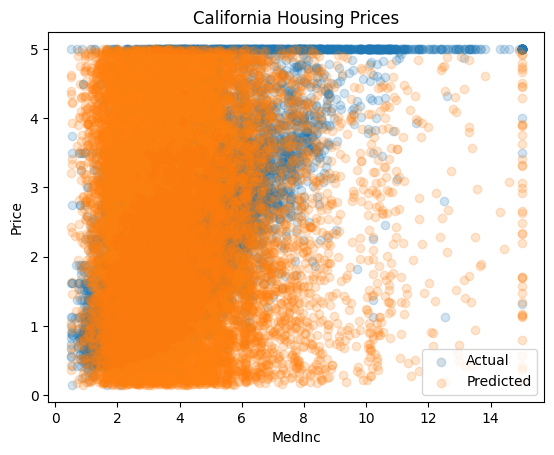

In [27]:
def random_predictor(y):
  y_pred = np.random.uniform(y.min(), y.max(), len(y))
  return y_pred

y_pred = random_predictor(y_train)
plot_predictions(y_train, y_pred)
plt.show()

In [28]:
def mean_error(y, y_pred):
  return np.mean((y - y_pred))

y_pred = average_predictor(y_train)
print(mean_error(y_train, y_pred))

3.6146796150586495e-17


In [29]:
def mean_absolute_error(y, y_pred):
  return np.mean(np.abs(y - y_pred))

y_pred = average_predictor(y_train)
print(mean_absolute_error(y_train, y_pred))

0.9139114988721792


In [39]:
y_pred = random_predictor(y_train)
print(mean_absolute_error(y_train, y_pred))

1.532811364195461


In [40]:
def mean_squared_error(y, y_pred):
  return np.mean((y - y_pred)**2)

y_pred = average_predictor(y_train)
print(mean_squared_error(y_train, y_pred))

1.336778211789427


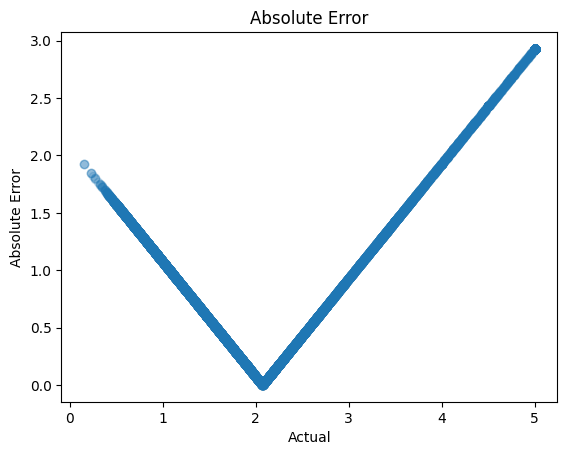

In [44]:
def plot_mae(y, y_pred):
  plt.scatter(y, np.abs(y - y_pred), alpha=0.2)
  plt.xlabel("Actual")
  plt.ylabel("Absolute Error")
  plt.title("Absolute Error")

plot_mae(y_train, y_pred)
plt.show()

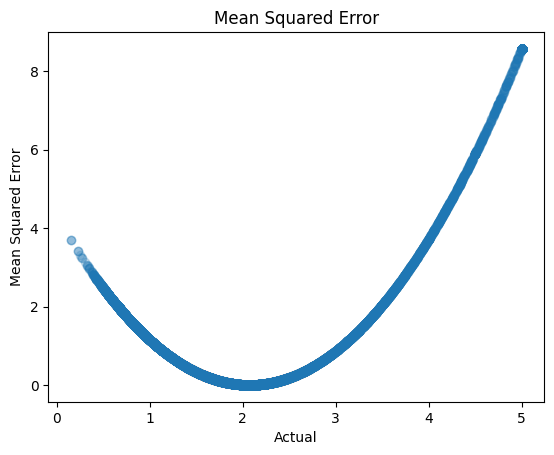

In [43]:
def plot_mse(y, y_pred):
  plt.scatter(y, (y - y_pred)**2, alpha=0.2)
  plt.xlabel("Actual")
  plt.ylabel("Mean Squared Error")
  plt.title("Mean Squared Error")

plot_mse(y_train, y_pred)
plt.show()

In [46]:
def root_mean_squared_error(y, y_pred):
  return np.sqrt(mean_squared_error(y, y_pred))

y_pred = average_predictor(y_train)
print(root_mean_squared_error(y_train, y_pred))

1.1561912522543263


# Regressão Linear Simples

$\hat y = \beta_0 + \beta_1x$



$\beta_0$: intercepto;
$\beta_1$: coeficiênte

2.3727078039874887


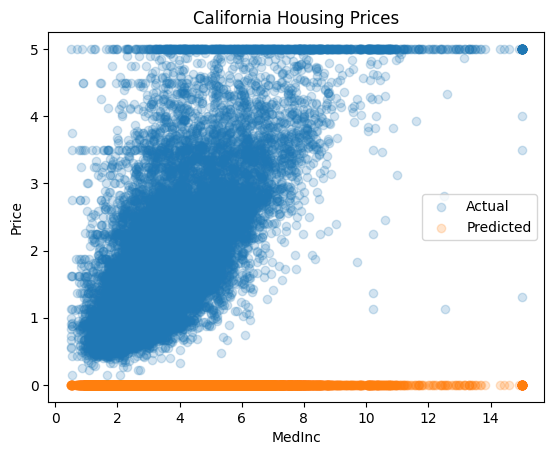

In [50]:
def linear_predictor(X, beta0=0, beta1=0, feature='MedInc'):
  y_pred = beta0 + beta1 * X[:, feature_names.index(feature)]
  return y_pred

y_pred = linear_predictor(X_train)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

1.1584276298447076


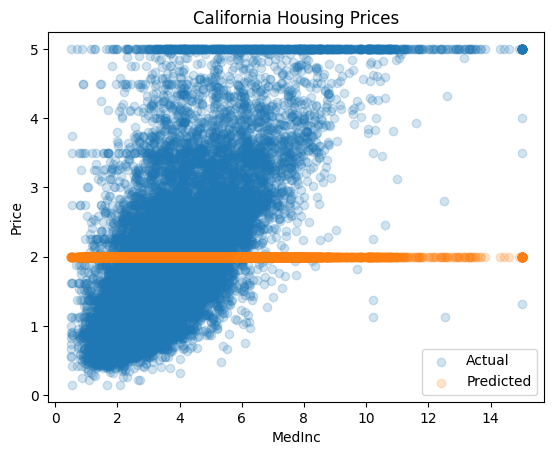

In [51]:
y_pred = linear_predictor(X_train, beta0=2)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

0.8602603388277182


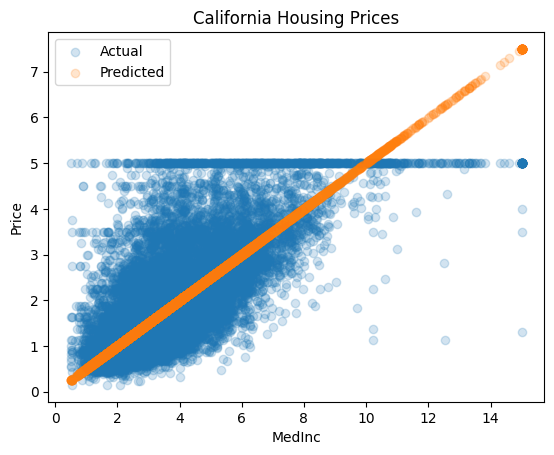

In [53]:
y_pred = linear_predictor(X_train, beta1=0.5)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

0.8587701839982896


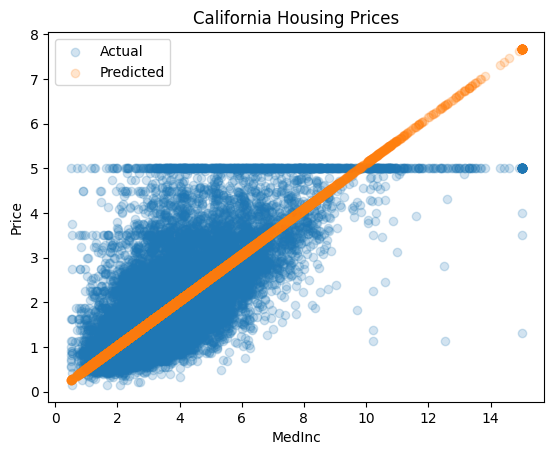

In [67]:
from os import error
from sklearn.base import BaseEstimator, RegressorMixin

class SimpleLinearRegression(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=1000, learning_rate=0.000001, feature='MedInc'):
    self.beta0 = 0
    self.beta1 = 0
    self.feature = feature
    self.max_iter = max_iter
    self.learning_rate = learning_rate
  def fit(self, X, y):
    for i in range(self.max_iter):
      y_pred = self.predict(X)
      error = y - y_pred
      self.beta0 += np.mean(error) * self.learning_rate
      self.beta1 += X[:, feature_names.index(self.feature)].T.dot(error) * self.learning_rate
    return self
  def predict(self, X):
    return self.beta0 + self.beta1 * X[:, feature_names.index(self.feature)]

model = SimpleLinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()

[-6.58759895e-15  4.87201795e-17  7.71091309e-15 -1.09747651e-15
  3.55013176e-18 -1.19414363e-16  7.99436690e-14 -3.88342056e-13]
[1.00234794 1.00134006 0.96491243 0.91412112 1.00405079 1.11482946
 1.0003277  1.00105298]


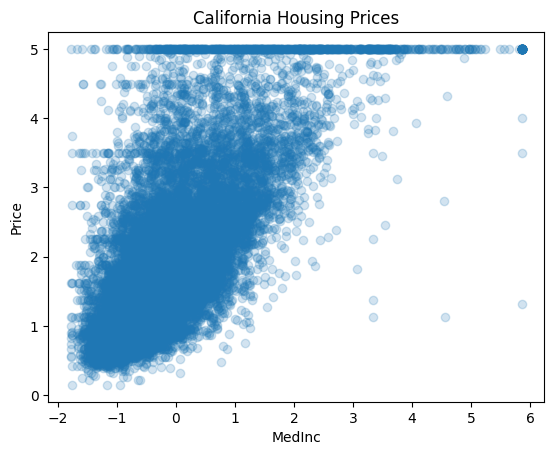

In [70]:
ave_train = X_train.mean(axis=0)
std_train = X.std(axis=0)

X_train_norm = (X_train - ave_train) / std_train
X_test_norm = (X_test - ave_train) / std_train

print(X_train_norm.mean(axis=0))
print(X_train_norm.std(axis=0))

plot_regression_dataset(X_train_norm, y_train)
plt.show()

0.8361487462514646


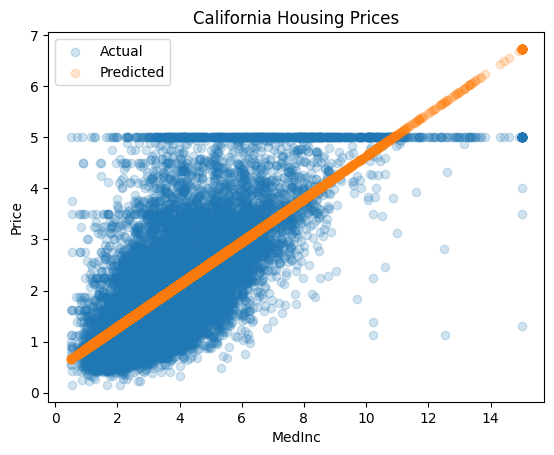

In [80]:
model = SimpleLinearRegression(max_iter=100000, learning_rate=0.0001)
model.fit(X_train_norm, y_train)
y_pred = model.predict(X_train_norm)
print(root_mean_squared_error(y_train, y_pred))
plot_predictions(y_train, y_pred)
plt.show()